In [1]:
from data_processing import prepare_features
from prediction import predict_flights
from routing import assign_flight
from routing import valid_route

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier



In [3]:
from sklearn.metrics import accuracy_score, classification_report

In [4]:
shipment_df = pd.read_csv("shipment_dataset.csv")

schedule_df = pd.read_csv("flight_schedule_dataset.csv")

routes_df = pd.read_csv("flight_routes_dataset.csv")

capacity_df = pd.read_csv("flight_capacity_dataset.csv")

C:\Users\9797487\AppData\Local\Temp\ipykernel_25188\49864299.py:1: DtypeWarning: Columns (3,4,5,6,8,9,11,12,13,14,15,16,17,18,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  shipment_df = pd.read_csv("shipment_dataset.csv")


In [5]:
day_map_num = {
    "Monday":1,
    "Tuesday":2,
    "Wednesday":3,
    "Thursday":4,
    "Friday":5,
    "Saturday":6,
    "Sunday":7
}

capacity_df["Day_Num"] = capacity_df["Day_of_Week"].astype(str).str.strip().map(day_map_num)

print("DEBUG:", capacity_df.columns)

DEBUG: Index(['Airline', 'Day_of_Week', 'Capacity_KG', 'Day_Num'], dtype='object')


In [6]:
capacity_df["Loaded_So_Far"] = 0  # New column to track loaded capacity
capacity_df["Remaining_Capacity"] = capacity_df["Capacity_KG"]  # New column to track remaining capacity
capacity_df["Load_Percentage"] = 0 # New column to track load percentage

In [7]:
capacity_df["Loaded_So_Far"] = capacity_df["Loaded_So_Far"].astype(float)  # Ensure this column is float for calculations
capacity_df["Capacity_KG"] = capacity_df["Capacity_KG"].astype(float)    # Ensure this column is float for calculations

In [8]:
shipment_df

,Unnamed: 0,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Unnamed: 7,Split,Flight_Number,...,ALH FIRST DATE(Flight takeoff from BOM),Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece
0,NaN,8.875315e+11,10.0,55.000,"2,36,190.810",Medium,IP,NaN,CDG,FX 5487,...,03-01-2026,FX,Thursday,3.0,7.0,4.0,Direct,CDG,3.0,5.500000
1,NaN,8.875360e+11,3.0,8.710,"1,28,056.500",Small,IP,NaN,CDG,FX 5487,...,03-01-2026,FX,Thursday,3.0,5.0,2.0,Direct,CDG,3.0,2.903333
2,NaN,8.875317e+11,3.0,21.030,"2,70,978.300",Small,IP,NaN,CDG,FX 5487,...,03-01-2026,FX,Thursday,3.0,6.0,3.0,Hub,MEM,3.0,7.010000
3,NaN,8.875314e+11,1.0,0.600,"47,461.500",Small,IP,NaN,CDG,FX 5487,...,03-01-2026,FX,Thursday,3.0,6.0,3.0,Hub,LHR,3.0,0.600000
4,NaN,8.875330e+11,1.0,6.500,"50,371.880",Small,IP,NaN,CDG,FX 5487,...,03-01-2026,FX,Thursday,3.0,5.0,2.0,Direct,CDG,3.0,6.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1046655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1046656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1046657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
schedule_df

,Flight_Number,Airline,Operating_Day
0,FX 5487,FX,Saturday
1,FX 5460,FX,Sunday
2,FX 0007,FX,Tuesday
3,FX 0007,FX,Wednesday
4,FX 0007,FX,Thursday
5,FX 0007,FX,Friday
6,AI 179,AI,Monday
7,AI 179,AI,Tuesday
8,AI 179,AI,Friday
9,AI 179,AI,Saturday


In [10]:
routes_df

,Flight_Number,Origin,Destination,Route_Type
0,6E 021,BOM,CDG,Direct
1,EK 507,BOM,DXB,Direct
2,QR 557,BOM,MEM,Direct
3,AI 179,BOM,MEM,Direct
4,FX 5487,BOM,CDG,Direct
5,FX 5487,CDG,MEM,Hub
6,FX 5487,CDG,LHR,Hub
7,FX 5460,BOM,CAN,Direct
8,FX 5460,CAN,MEM,Hub
9,FX 0007,BOM,DXB,Direct


In [11]:
capacity_df

,Airline,Day_of_Week,Capacity_KG,Day_Num,Loaded_So_Far,Remaining_Capacity,Load_Percentage
0,EK,Sunday,4950.0,7,0.0,4950,0
1,AI,Monday,8250.0,1,0.0,8250,0
2,AI,Tuesday,8250.0,2,0.0,8250,0
3,AI,Friday,8250.0,5,0.0,8250,0
4,AI,Saturday,8250.0,6,0.0,8250,0
5,QR,Tuesday,4950.0,2,0.0,4950,0
6,QR,Wednesday,4950.0,3,0.0,4950,0
7,QR,Thursday,4950.0,4,0.0,4950,0
8,QR,Friday,4950.0,5,0.0,4950,0
9,QR,Saturday,3300.0,6,0.0,3300,0


In [12]:
print(shipment_df.shape)
print(schedule_df.shape)
print(routes_df.shape)
print(capacity_df.shape)

(1046659, 26)
(23, 3)
(11, 4)
(23, 7)


In [13]:
shipment_df = shipment_df.dropna(how="all") # Drop rows where all elements are NaN

In [14]:
shipment_df.head()

,Unnamed: 0,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Unnamed: 7,Split,Flight_Number,...,ALH FIRST DATE(Flight takeoff from BOM),Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece
0,NaN,8.875315e+11,10.0,55.000,"2,36,190.810",Medium,IP,NaN,CDG,FX 5487,...,03-01-2026,FX,Thursday,3.0,7.0,4.0,Direct,CDG,3.0,5.500000
1,NaN,8.875360e+11,3.0,8.710,"1,28,056.500",Small,IP,NaN,CDG,FX 5487,...,03-01-2026,FX,Thursday,3.0,5.0,2.0,Direct,CDG,3.0,2.903333
2,NaN,8.875317e+11,3.0,21.030,"2,70,978.300",Small,IP,NaN,CDG,FX 5487,...,03-01-2026,FX,Thursday,3.0,6.0,3.0,Hub,MEM,3.0,7.010000
3,NaN,8.875314e+11,1.0,0.600,"47,461.500",Small,IP,NaN,CDG,FX 5487,...,03-01-2026,FX,Thursday,3.0,6.0,3.0,Hub,LHR,3.0,0.600000
4,NaN,8.875330e+11,1.0,6.500,"50,371.880",Small,IP,NaN,CDG,FX 5487,...,03-01-2026,FX,Thursday,3.0,5.0,2.0,Direct,CDG,3.0,6.500000


In [15]:
shipment_df = shipment_df.dropna(subset=["Weight"]) # Drop rows where 'Weight' is NaN

In [16]:
shipment_df = shipment_df.drop(columns=["Unnamed: 0","Unnamed: 7"], errors="ignore") # Drop unnecessary columns if they exist

In [17]:
shipment_df["Weight"] = shipment_df["Weight"].astype(str).str.replace(",","")
shipment_df["Weight"] = pd.to_numeric(shipment_df["Weight"], errors="coerce")

In [18]:
shipment_df["Invoice Value"] = shipment_df["Invoice Value"].astype(str).str.replace(",","")
shipment_df["Invoice Value"] = pd.to_numeric(shipment_df["Invoice Value"], errors="coerce")

In [19]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Clearence_Delay,Shipment Pickup Date,...,ALH FIRST DATE(Flight takeoff from BOM),Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece
0,8.875315e+11,10.0,55.00,236190.81,Medium,IP,CDG,FX 5487,1.0,31-12-2025,...,03-01-2026,FX,Thursday,3.0,7.0,4.0,Direct,CDG,3.0,5.500000
1,8.875360e+11,3.0,8.71,128056.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,03-01-2026,FX,Thursday,3.0,5.0,2.0,Direct,CDG,3.0,2.903333
2,8.875317e+11,3.0,21.03,270978.30,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,03-01-2026,FX,Thursday,3.0,6.0,3.0,Hub,MEM,3.0,7.010000
3,8.875314e+11,1.0,0.60,47461.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,03-01-2026,FX,Thursday,3.0,6.0,3.0,Hub,LHR,3.0,0.600000
4,8.875330e+11,1.0,6.50,50371.88,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,03-01-2026,FX,Thursday,3.0,5.0,2.0,Direct,CDG,3.0,6.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5248,4.919201e+11,2.0,35.20,1875423.28,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,01-02-2026,FX,Saturday,2.0,6.0,4.0,Hub,MEM,5.0,17.600000
5249,4.362237e+11,1.0,4.30,83002.45,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,01-02-2026,FX,Saturday,2.0,5.0,3.0,Direct,CAN,5.0,4.300000
5250,4.362237e+11,1.0,14.00,481925.18,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,01-02-2026,FX,Saturday,2.0,6.0,4.0,Hub,MEM,5.0,14.000000
5251,4.362237e+11,3.0,37.80,782311.96,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,01-02-2026,FX,Saturday,2.0,3.0,1.0,Direct,CAN,5.0,12.600000


In [20]:
shipment_df.isnull().sum() #checking for any remaining null values

AWB                                                  0
Pieces                                               0
Weight                                               0
Invoice Value                                        0
Weight_Category                                      0
Service                                              0
Split                                                0
Flight_Number                                        0
Clearence_Delay                                      0
Shipment Pickup Date                                 0
Shipment Pickup_DOW                                  0
Shipment received date by the CLH team               0
Shipment Handover date to Ramp by the CLH Team       0
Commit Date                                          0
ALH FIRST DATE(Flight takeoff from BOM)              0
Airline_Code                                         0
Shipment handover day to the ramp                    0
NO.Of Days between Pickup Date and Flight Takeoff    0
Delivery_W

In [21]:
shipment_df = shipment_df.dropna() # Drop any remaining rows with NaN values after conversion

In [22]:
def urgency_level(x):

    if x <= 3:
        return "Critical"
    elif x <= 5:
        return "High"
    elif x <= 7:
        return "Medium"
    else:
        return "Low"

shipment_df["Urgency_Level"] = shipment_df["Delivery_Window"].apply(urgency_level)

In [23]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Clearence_Delay,Shipment Pickup Date,...,Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,Urgency_Level
0,8.875315e+11,10.0,55.00,236190.81,Medium,IP,CDG,FX 5487,1.0,31-12-2025,...,FX,Thursday,3.0,7.0,4.0,Direct,CDG,3.0,5.500000,Medium
1,8.875360e+11,3.0,8.71,128056.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,FX,Thursday,3.0,5.0,2.0,Direct,CDG,3.0,2.903333,High
2,8.875317e+11,3.0,21.03,270978.30,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,FX,Thursday,3.0,6.0,3.0,Hub,MEM,3.0,7.010000,Medium
3,8.875314e+11,1.0,0.60,47461.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,FX,Thursday,3.0,6.0,3.0,Hub,LHR,3.0,0.600000,Medium
4,8.875330e+11,1.0,6.50,50371.88,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,FX,Thursday,3.0,5.0,2.0,Direct,CDG,3.0,6.500000,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5248,4.919201e+11,2.0,35.20,1875423.28,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,FX,Saturday,2.0,6.0,4.0,Hub,MEM,5.0,17.600000,Medium
5249,4.362237e+11,1.0,4.30,83002.45,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,FX,Saturday,2.0,5.0,3.0,Direct,CAN,5.0,4.300000,High
5250,4.362237e+11,1.0,14.00,481925.18,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,FX,Saturday,2.0,6.0,4.0,Hub,MEM,5.0,14.000000,Medium
5251,4.362237e+11,3.0,37.80,782311.96,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,FX,Saturday,2.0,3.0,1.0,Direct,CAN,5.0,12.600000,Critical


In [24]:
shipment_df["Weekend_Pickup"] = shipment_df["Pickup Weekday Number"].apply(
    lambda x: 1 if x >= 6 else 0
)  # Create a binary feature for weekend pickups (1 for Saturday/Sunday, 0 for weekdays)

In [25]:
shipment_df["Service"] = shipment_df["Service"].str.upper()

priority_map = {
    "IP":1,
    "IPF":2,
    "IE":3,
    "IEF":4
}

shipment_df["Service_Priority"] = shipment_df["Service"].map(priority_map)

In [26]:
shipment_df["Flight_Number"] = shipment_df["Flight_Number"].str.strip()
shipment_df["Flight_Number"] = shipment_df["Flight_Number"].str.replace(r'\s+', ' ', regex=True)

In [27]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Clearence_Delay,Shipment Pickup Date,...,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,Urgency_Level,Weekend_Pickup,Service_Priority
0,8.875315e+11,10.0,55.00,236190.81,Medium,IP,CDG,FX 5487,1.0,31-12-2025,...,3.0,7.0,4.0,Direct,CDG,3.0,5.500000,Medium,0,1
1,8.875360e+11,3.0,8.71,128056.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,3.0,5.0,2.0,Direct,CDG,3.0,2.903333,High,0,1
2,8.875317e+11,3.0,21.03,270978.30,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,3.0,6.0,3.0,Hub,MEM,3.0,7.010000,Medium,0,1
3,8.875314e+11,1.0,0.60,47461.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,3.0,6.0,3.0,Hub,LHR,3.0,0.600000,Medium,0,1
4,8.875330e+11,1.0,6.50,50371.88,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,3.0,5.0,2.0,Direct,CDG,3.0,6.500000,High,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5248,4.919201e+11,2.0,35.20,1875423.28,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,2.0,6.0,4.0,Hub,MEM,5.0,17.600000,Medium,0,1
5249,4.362237e+11,1.0,4.30,83002.45,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,2.0,5.0,3.0,Direct,CAN,5.0,4.300000,High,0,1
5250,4.362237e+11,1.0,14.00,481925.18,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,2.0,6.0,4.0,Hub,MEM,5.0,14.000000,Medium,0,1
5251,4.362237e+11,3.0,37.80,782311.96,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,2.0,3.0,1.0,Direct,CAN,5.0,12.600000,Critical,0,1


In [28]:
schedule_df

,Flight_Number,Airline,Operating_Day
0,FX 5487,FX,Saturday
1,FX 5460,FX,Sunday
2,FX 0007,FX,Tuesday
3,FX 0007,FX,Wednesday
4,FX 0007,FX,Thursday
5,FX 0007,FX,Friday
6,AI 179,AI,Monday
7,AI 179,AI,Tuesday
8,AI 179,AI,Friday
9,AI 179,AI,Saturday


In [29]:
routes_df

,Flight_Number,Origin,Destination,Route_Type
0,6E 021,BOM,CDG,Direct
1,EK 507,BOM,DXB,Direct
2,QR 557,BOM,MEM,Direct
3,AI 179,BOM,MEM,Direct
4,FX 5487,BOM,CDG,Direct
5,FX 5487,CDG,MEM,Hub
6,FX 5487,CDG,LHR,Hub
7,FX 5460,BOM,CAN,Direct
8,FX 5460,CAN,MEM,Hub
9,FX 0007,BOM,DXB,Direct


In [30]:
capacity_df

,Airline,Day_of_Week,Capacity_KG,Day_Num,Loaded_So_Far,Remaining_Capacity,Load_Percentage
0,EK,Sunday,4950.0,7,0.0,4950,0
1,AI,Monday,8250.0,1,0.0,8250,0
2,AI,Tuesday,8250.0,2,0.0,8250,0
3,AI,Friday,8250.0,5,0.0,8250,0
4,AI,Saturday,8250.0,6,0.0,8250,0
5,QR,Tuesday,4950.0,2,0.0,4950,0
6,QR,Wednesday,4950.0,3,0.0,4950,0
7,QR,Thursday,4950.0,4,0.0,4950,0
8,QR,Friday,4950.0,5,0.0,4950,0
9,QR,Saturday,3300.0,6,0.0,3300,0


In [31]:
shipment_df = shipment_df.merge(
    schedule_df,
    on="Flight_Number",
    how="left"
)

In [32]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Clearence_Delay,Shipment Pickup Date,...,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,Urgency_Level,Weekend_Pickup,Service_Priority,Airline,Operating_Day
0,8.875315e+11,10.0,55.00,236190.81,Medium,IP,CDG,FX 5487,1.0,31-12-2025,...,4.0,Direct,CDG,3.0,5.500000,Medium,0,1,FX,Saturday
1,8.875360e+11,3.0,8.71,128056.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,2.0,Direct,CDG,3.0,2.903333,High,0,1,FX,Saturday
2,8.875317e+11,3.0,21.03,270978.30,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,3.0,Hub,MEM,3.0,7.010000,Medium,0,1,FX,Saturday
3,8.875314e+11,1.0,0.60,47461.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,3.0,Hub,LHR,3.0,0.600000,Medium,0,1,FX,Saturday
4,8.875330e+11,1.0,6.50,50371.88,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,2.0,Direct,CDG,3.0,6.500000,High,0,1,FX,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7227,4.919201e+11,2.0,35.20,1875423.28,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,4.0,Hub,MEM,5.0,17.600000,Medium,0,1,FX,Sunday
7228,4.362237e+11,1.0,4.30,83002.45,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,3.0,Direct,CAN,5.0,4.300000,High,0,1,FX,Sunday
7229,4.362237e+11,1.0,14.00,481925.18,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,4.0,Hub,MEM,5.0,14.000000,Medium,0,1,FX,Sunday
7230,4.362237e+11,3.0,37.80,782311.96,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,1.0,Direct,CAN,5.0,12.600000,Critical,0,1,FX,Sunday


In [33]:
shipment_df["Flight_Number"].unique()

array(['FX 5487', 'QR 557', 'FX 0007', 'FX 5460', 'AI 179', 'EK 507',
       '6E 021'], dtype=object)

In [34]:
shipment_df["Destination_Hub"].unique()

array(['CDG', 'MEM', 'LHR', 'CAN', 'DXB'], dtype=object)

In [35]:
shipment_df["Split"].unique()

array(['CDG', 'MEM', 'DXB', 'CAN'], dtype=object)

In [36]:
day_map = {
"Monday":1,
"Tuesday":2,
"Wednesday":3,
"Thursday":4,
"Friday":5,
"Saturday":6,
"Sunday":7
}

shipment_df["Operating_Day_Num"] = shipment_df["Operating_Day"].map(day_map)

In [37]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Clearence_Delay,Shipment Pickup Date,...,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,Urgency_Level,Weekend_Pickup,Service_Priority,Airline,Operating_Day,Operating_Day_Num
0,8.875315e+11,10.0,55.00,236190.81,Medium,IP,CDG,FX 5487,1.0,31-12-2025,...,Direct,CDG,3.0,5.500000,Medium,0,1,FX,Saturday,6
1,8.875360e+11,3.0,8.71,128056.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,Direct,CDG,3.0,2.903333,High,0,1,FX,Saturday,6
2,8.875317e+11,3.0,21.03,270978.30,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,Hub,MEM,3.0,7.010000,Medium,0,1,FX,Saturday,6
3,8.875314e+11,1.0,0.60,47461.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,Hub,LHR,3.0,0.600000,Medium,0,1,FX,Saturday,6
4,8.875330e+11,1.0,6.50,50371.88,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,Direct,CDG,3.0,6.500000,High,0,1,FX,Saturday,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7227,4.919201e+11,2.0,35.20,1875423.28,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,Hub,MEM,5.0,17.600000,Medium,0,1,FX,Sunday,7
7228,4.362237e+11,1.0,4.30,83002.45,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,Direct,CAN,5.0,4.300000,High,0,1,FX,Sunday,7
7229,4.362237e+11,1.0,14.00,481925.18,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,Hub,MEM,5.0,14.000000,Medium,0,1,FX,Sunday,7
7230,4.362237e+11,3.0,37.80,782311.96,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,Direct,CAN,5.0,12.600000,Critical,0,1,FX,Sunday,7


In [38]:
shipment_df["Days_to_Flight"] = (
shipment_df["Operating_Day_Num"]
-
shipment_df["Pickup Weekday Number"]
)

In [39]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Clearence_Delay,Shipment Pickup Date,...,Destination_Hub,Pickup Weekday Number,Weight per Piece,Urgency_Level,Weekend_Pickup,Service_Priority,Airline,Operating_Day,Operating_Day_Num,Days_to_Flight
0,8.875315e+11,10.0,55.00,236190.81,Medium,IP,CDG,FX 5487,1.0,31-12-2025,...,CDG,3.0,5.500000,Medium,0,1,FX,Saturday,6,3.0
1,8.875360e+11,3.0,8.71,128056.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,CDG,3.0,2.903333,High,0,1,FX,Saturday,6,3.0
2,8.875317e+11,3.0,21.03,270978.30,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,MEM,3.0,7.010000,Medium,0,1,FX,Saturday,6,3.0
3,8.875314e+11,1.0,0.60,47461.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,LHR,3.0,0.600000,Medium,0,1,FX,Saturday,6,3.0
4,8.875330e+11,1.0,6.50,50371.88,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,CDG,3.0,6.500000,High,0,1,FX,Saturday,6,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7227,4.919201e+11,2.0,35.20,1875423.28,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,MEM,5.0,17.600000,Medium,0,1,FX,Sunday,7,2.0
7228,4.362237e+11,1.0,4.30,83002.45,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,CAN,5.0,4.300000,High,0,1,FX,Sunday,7,2.0
7229,4.362237e+11,1.0,14.00,481925.18,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,MEM,5.0,14.000000,Medium,0,1,FX,Sunday,7,2.0
7230,4.362237e+11,3.0,37.80,782311.96,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,CAN,5.0,12.600000,Critical,0,1,FX,Sunday,7,2.0


In [40]:
shipment_df["Days_to_Flight"] = shipment_df["Days_to_Flight"].apply(
lambda x: x+7 if x<0 else x
) # Adjust negative values to represent days until next week's flight

In [41]:
shipment_df["Flight_Number"].unique()

array(['FX 5487', 'QR 557', 'FX 0007', 'FX 5460', 'AI 179', 'EK 507',
       '6E 021'], dtype=object)

In [42]:
shipment_df.isnull().sum() #checking for any remaining null values

AWB                                                  0
Pieces                                               0
Weight                                               0
Invoice Value                                        0
Weight_Category                                      0
Service                                              0
Split                                                0
Flight_Number                                        0
Clearence_Delay                                      0
Shipment Pickup Date                                 0
Shipment Pickup_DOW                                  0
Shipment received date by the CLH team               0
Shipment Handover date to Ramp by the CLH Team       0
Commit Date                                          0
ALH FIRST DATE(Flight takeoff from BOM)              0
Airline_Code                                         0
Shipment handover day to the ramp                    0
NO.Of Days between Pickup Date and Flight Takeoff    0
Delivery_W

In [43]:
shipment_df = shipment_df.merge(
capacity_df,
left_on=["Airline","Operating_Day"],
right_on=["Airline","Day_of_Week"],
how="left"
)

In [44]:
shipment_df.isnull().sum() #checking for any remaining null values

AWB                                                  0
Pieces                                               0
Weight                                               0
Invoice Value                                        0
Weight_Category                                      0
Service                                              0
Split                                                0
Flight_Number                                        0
Clearence_Delay                                      0
Shipment Pickup Date                                 0
Shipment Pickup_DOW                                  0
Shipment received date by the CLH team               0
Shipment Handover date to Ramp by the CLH Team       0
Commit Date                                          0
ALH FIRST DATE(Flight takeoff from BOM)              0
Airline_Code                                         0
Shipment handover day to the ramp                    0
NO.Of Days between Pickup Date and Flight Takeoff    0
Delivery_W

In [45]:
shipment_df["Flight_Number"].unique()

array(['FX 5487', 'QR 557', 'FX 0007', 'FX 5460', 'AI 179', 'EK 507',
       '6E 021'], dtype=object)

In [46]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Clearence_Delay,Shipment Pickup Date,...,Airline,Operating_Day,Operating_Day_Num,Days_to_Flight,Day_of_Week,Capacity_KG,Day_Num,Loaded_So_Far,Remaining_Capacity,Load_Percentage
0,8.875315e+11,10.0,55.00,236190.81,Medium,IP,CDG,FX 5487,1.0,31-12-2025,...,FX,Saturday,6,3.0,Saturday,60000.0,6,0.0,60000,0
1,8.875360e+11,3.0,8.71,128056.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,FX,Saturday,6,3.0,Saturday,60000.0,6,0.0,60000,0
2,8.875317e+11,3.0,21.03,270978.30,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,FX,Saturday,6,3.0,Saturday,60000.0,6,0.0,60000,0
3,8.875314e+11,1.0,0.60,47461.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,FX,Saturday,6,3.0,Saturday,60000.0,6,0.0,60000,0
4,8.875330e+11,1.0,6.50,50371.88,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,FX,Saturday,6,3.0,Saturday,60000.0,6,0.0,60000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7227,4.919201e+11,2.0,35.20,1875423.28,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,FX,Sunday,7,2.0,Sunday,60000.0,7,0.0,60000,0
7228,4.362237e+11,1.0,4.30,83002.45,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,FX,Sunday,7,2.0,Sunday,60000.0,7,0.0,60000,0
7229,4.362237e+11,1.0,14.00,481925.18,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,FX,Sunday,7,2.0,Sunday,60000.0,7,0.0,60000,0
7230,4.362237e+11,3.0,37.80,782311.96,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,FX,Sunday,7,2.0,Sunday,60000.0,7,0.0,60000,0


In [47]:
shipment_df["Capacity_Ratio"] = shipment_df["Weight"] /shipment_df["Capacity_KG"] # Create a new feature representing the ratio of shipment weight to flight capacity
# % of flight capacity used by the shipment

In [48]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Clearence_Delay,Shipment Pickup Date,...,Operating_Day,Operating_Day_Num,Days_to_Flight,Day_of_Week,Capacity_KG,Day_Num,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Capacity_Ratio
0,8.875315e+11,10.0,55.00,236190.81,Medium,IP,CDG,FX 5487,1.0,31-12-2025,...,Saturday,6,3.0,Saturday,60000.0,6,0.0,60000,0,0.000917
1,8.875360e+11,3.0,8.71,128056.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,Saturday,6,3.0,Saturday,60000.0,6,0.0,60000,0,0.000145
2,8.875317e+11,3.0,21.03,270978.30,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,Saturday,6,3.0,Saturday,60000.0,6,0.0,60000,0,0.000351
3,8.875314e+11,1.0,0.60,47461.50,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,Saturday,6,3.0,Saturday,60000.0,6,0.0,60000,0,0.000010
4,8.875330e+11,1.0,6.50,50371.88,Small,IP,CDG,FX 5487,1.0,31-12-2025,...,Saturday,6,3.0,Saturday,60000.0,6,0.0,60000,0,0.000108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7227,4.919201e+11,2.0,35.20,1875423.28,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,Sunday,7,2.0,Sunday,60000.0,7,0.0,60000,0,0.000587
7228,4.362237e+11,1.0,4.30,83002.45,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,Sunday,7,2.0,Sunday,60000.0,7,0.0,60000,0,0.000072
7229,4.362237e+11,1.0,14.00,481925.18,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,Sunday,7,2.0,Sunday,60000.0,7,0.0,60000,0,0.000233
7230,4.362237e+11,3.0,37.80,782311.96,Small,IP,CAN,FX 5460,1.0,30-01-2026,...,Sunday,7,2.0,Sunday,60000.0,7,0.0,60000,0,0.000630


In [49]:
print(shipment_df.columns)

Index(['AWB', 'Pieces', 'Weight', 'Invoice Value', 'Weight_Category',
       'Service', 'Split', 'Flight_Number', 'Clearence_Delay',
       'Shipment Pickup Date', 'Shipment Pickup_DOW',
       'Shipment received date by the CLH team',
       'Shipment Handover date to Ramp by the CLH Team', 'Commit Date',
       'ALH FIRST DATE(Flight takeoff from BOM)', 'Airline_Code',
       'Shipment handover day to the ramp',
       'NO.Of Days between Pickup Date and Flight Takeoff', 'Delivery_Window',
       'NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE', 'Route_Type',
       'Destination_Hub', 'Pickup Weekday Number', 'Weight per Piece',
       'Urgency_Level', 'Weekend_Pickup', 'Service_Priority', 'Airline',
       'Operating_Day', 'Operating_Day_Num', 'Days_to_Flight', 'Day_of_Week',
       'Capacity_KG', 'Day_Num', 'Loaded_So_Far', 'Remaining_Capacity',
       'Load_Percentage', 'Capacity_Ratio'],
      dtype='object')


In [50]:
shipment_df["Shipment Pickup Date"] = pd.to_datetime(
    shipment_df["Shipment Pickup Date"], dayfirst=True
)

shipment_df["ALH FIRST DATE(Flight takeoff from BOM)"] = pd.to_datetime(
    shipment_df["ALH FIRST DATE(Flight takeoff from BOM)"], dayfirst=True
)


In [51]:
shipment_df[[
    "Shipment Pickup Date",
    "ALH FIRST DATE(Flight takeoff from BOM)"
]].head()

,Shipment Pickup Date,ALH FIRST DATE(Flight takeoff from BOM)
0,2025-12-31,2026-01-03
1,2025-12-31,2026-01-03
2,2025-12-31,2026-01-03
3,2025-12-31,2026-01-03
4,2025-12-31,2026-01-03


In [52]:
shipment_df["Shipment Pickup Date"] = pd.to_datetime(   # Convert to datetime format
    shipment_df["Shipment Pickup Date"], dayfirst=True    # Specify dayfirst=True since the date format is likely DD/MM/YYYY
)

shipment_df.rename(
    columns={"ALH FIRST DATE(Flight takeoff from BOM)": "Flight_Takeoff_Date"},   # Rename column for clarity
    inplace=True
)

shipment_df["Flight_Takeoff_Date"] = pd.to_datetime(               # Convert to datetime format
    shipment_df["Flight_Takeoff_Date"], dayfirst=True             # Specify dayfirst=True since the date format is likely DD/MM/YYYY
)

In [53]:
shipment_df = shipment_df.sort_values(
    ["Flight_Number","Flight_Takeoff_Date","Shipment Pickup Date","Weight"]
)

shipment_df["Loaded_So_Far"] = shipment_df.groupby(
    ["Flight_Number","Flight_Takeoff_Date"]
)["Weight"].cumsum()

shipment_df["Remaining_Capacity"] = (
    shipment_df["Capacity_KG"] - shipment_df["Loaded_So_Far"]
)
shipment_df["Remaining_Capacity"] = shipment_df["Remaining_Capacity"].clip(lower=0) # Ensure remaining capacity doesn't go negative

shipment_df["Load_Percentage"] = (
    shipment_df["Loaded_So_Far"] / shipment_df["Capacity_KG"]
)

shipment_df["Load_Percentage"] = shipment_df["Load_Percentage"].clip(0,1)

shipment_df["Flight_Full"] = (
    shipment_df["Remaining_Capacity"] <= 0
).astype(int)

In [54]:
shipment_df[[
"Flight_Number",
"Flight_Takeoff_Date",
"Weight",
"Capacity_KG",
"Loaded_So_Far",
"Remaining_Capacity",
"Load_Percentage"
]].head(15)

,Flight_Number,Flight_Takeoff_Date,Weight,Capacity_KG,Loaded_So_Far,Remaining_Capacity,Load_Percentage
4458,6E 021,2026-01-20,29.0,1650.0,29.0,1621.0,0.017576
4459,6E 021,2026-01-20,29.0,1650.0,58.0,1592.0,0.035152
4460,6E 021,2026-01-20,29.0,1650.0,87.0,1563.0,0.052727
4461,6E 021,2026-01-20,29.0,1650.0,116.0,1534.0,0.070303
4462,6E 021,2026-01-20,29.0,1650.0,145.0,1505.0,0.087879
4463,6E 021,2026-01-20,29.0,1650.0,174.0,1476.0,0.105455
4368,6E 021,2026-01-20,75.0,1650.0,249.0,1401.0,0.150909
4369,6E 021,2026-01-20,75.0,1650.0,324.0,1326.0,0.196364
4370,6E 021,2026-01-20,75.0,1650.0,399.0,1251.0,0.241818
4371,6E 021,2026-01-20,75.0,1650.0,474.0,1176.0,0.287273


In [55]:
shipment_df.describe()

,AWB,Pieces,Weight,Invoice Value,Clearence_Delay,Shipment Pickup Date,Flight_Takeoff_Date,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,...,Service_Priority,Operating_Day_Num,Days_to_Flight,Capacity_KG,Day_Num,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Capacity_Ratio,Flight_Full
count,7.232000e+03,7232.000000,7232.000000,7.232000e+03,7232.000000,7232,7232,7232.000000,7232.000000,7232.000000,...,7232.000000,7232.000000,7232.000000,7232.000000,7232.000000,7232.000000,7232.000000,7232.000000,7232.000000,7232.000000
mean,8.108723e+11,3.053512,74.681453,5.372527e+05,1.066233,2026-01-14 07:26:13.008849664,2026-01-17 22:12:52.566371840,3.615736,7.863523,4.247788,...,1.939851,4.900028,2.922981,26915.915376,4.900028,6614.858363,20933.140303,0.370682,0.012961,0.154591
min,3.971833e+11,1.000000,0.100000,-1.208930e+03,0.000000,2025-11-28 00:00:00,2026-01-02 00:00:00,0.000000,3.000000,-36.000000,...,1.000000,1.000000,0.000000,1650.000000,1.000000,0.500000,0.000000,0.000017,0.000008,0.000000
25%,8.875542e+11,1.000000,6.500000,4.022890e+04,1.000000,2026-01-07 00:00:00,2026-01-10 00:00:00,3.000000,6.000000,3.000000,...,1.000000,4.000000,2.000000,4950.000000,4.000000,799.450000,1878.425000,0.064241,0.000283,0.000000
50%,8.877899e+11,1.000000,21.000000,1.059981e+05,1.000000,2026-01-14 00:00:00,2026-01-17 00:00:00,3.000000,7.000000,4.000000,...,1.000000,6.000000,3.000000,8250.000000,6.000000,3098.000000,5674.800000,0.262222,0.001667,0.000000
75%,8.880439e+11,3.000000,70.500000,2.993760e+05,1.000000,2026-01-21 00:00:00,2026-01-24 00:00:00,4.000000,9.000000,6.000000,...,3.000000,6.000000,4.000000,60000.000000,6.000000,9374.823000,46054.100000,0.579773,0.008687,0.000000
max,8.883410e+11,148.000000,5576.000000,4.833000e+07,14.000000,2026-01-30 00:00:00,2026-02-03 00:00:00,43.000000,38.000000,33.000000,...,4.000000,7.000000,6.000000,60000.000000,7.000000,46233.800000,59999.000000,1.000000,0.775758,1.000000
std,1.744330e+11,5.479047,195.979885,2.177676e+06,0.836460,NaN,NaN,1.737556,2.546981,2.730052,...,1.049780,1.806070,1.773828,26719.819117,1.806070,8584.427022,23374.378656,0.349658,0.038213,0.361539


In [56]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Clearence_Delay,Shipment Pickup Date,...,Operating_Day_Num,Days_to_Flight,Day_of_Week,Capacity_KG,Day_Num,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Capacity_Ratio,Flight_Full
4458,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,2,0.0,Tuesday,1650.0,2,29.0,1621.0,0.017576,0.017576,0
4459,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,3,1.0,Wednesday,1650.0,3,58.0,1592.0,0.035152,0.017576,0
4460,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,4,2.0,Thursday,1650.0,4,87.0,1563.0,0.052727,0.017576,0
4461,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,5,3.0,Friday,1650.0,5,116.0,1534.0,0.070303,0.017576,0
4462,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,6,4.0,Saturday,1650.0,6,145.0,1505.0,0.087879,0.017576,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR 557,1.0,2026-01-29,...,3,6.0,Wednesday,4950.0,3,949.0,4001.0,0.191717,0.001616,0
227,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR 557,1.0,2026-01-29,...,4,0.0,Thursday,4950.0,4,957.0,3993.0,0.193333,0.001616,0
228,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR 557,1.0,2026-01-29,...,5,1.0,Friday,4950.0,5,965.0,3985.0,0.194949,0.001616,0
229,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR 557,1.0,2026-01-29,...,6,2.0,Saturday,3300.0,6,973.0,2327.0,0.294848,0.002424,0


In [57]:
shipment_df.apply(lambda x: x.duplicated().sum())

AWB                                                  3616
Pieces                                               7186
Weight                                               6536
Invoice Value                                        4135
Weight_Category                                      7229
Service                                              7228
Split                                                7228
Flight_Number                                        7225
Clearence_Delay                                      7221
Shipment Pickup Date                                 7195
Shipment Pickup_DOW                                  7225
Shipment received date by the CLH team               7195
Shipment Handover date to Ramp by the CLH Team       7203
Commit Date                                          7184
Flight_Takeoff_Date                                  7199
Airline_Code                                         7226
Shipment handover day to the ramp                    7225
NO.Of Days bet

In [58]:
shipment_df["Flight_Full"].value_counts()

Flight_Full
0    6114
1    1118
Name: count, dtype: int64

## Destination vs Flight

In [59]:
pd.crosstab(shipment_df["Flight_Number"], shipment_df["Destination_Hub"])

Destination_Hub,CAN,CDG,DXB,LHR,MEM
Flight_Number,,,,,
6E 021,0,222,0,0,0
AI 179,0,0,0,0,1484
EK 507,0,0,210,0,3
FX 0007,0,308,0,0,0
FX 5460,169,0,0,0,175
FX 5487,0,1549,0,11,635
QR 557,0,0,0,0,2466


## Split vs Flight_Number

In [60]:
pd.crosstab(shipment_df["Flight_Number"], shipment_df["Split"])

Split,CAN,CDG,DXB,MEM
Flight_Number,,,,
6E 021,0,222,0,0
AI 179,0,0,0,1484
EK 507,0,0,213,0
FX 0007,0,0,308,0
FX 5460,344,0,0,0
FX 5487,0,2195,0,0
QR 557,0,0,0,2466


## Flight vs Service

In [61]:
pd.crosstab(shipment_df["Service"], shipment_df["Flight_Number"])

Flight_Number,6E 021,AI 179,EK 507,FX 0007,FX 5460,FX 5487,QR 557
Service,,,,,,,
IE,198,740,56,0,69,467,1056
IEF,24,64,8,0,9,83,210
IP,0,600,138,308,263,1518,990
IPF,0,80,11,0,3,127,210


## Flight vs Pickup Day

In [62]:
pd.crosstab(shipment_df["Pickup Weekday Number"], shipment_df["Flight_Number"])

Flight_Number,6E 021,AI 179,EK 507,FX 0007,FX 5460,FX 5487,QR 557
Pickup Weekday Number,,,,,,,
1.0,24,68,1,0,6,203,330
2.0,42,144,7,28,17,597,606
3.0,36,596,23,36,10,598,282
4.0,12,292,19,56,45,373,366
5.0,72,288,163,180,265,220,408
6.0,36,92,0,8,1,195,456
7.0,0,4,0,0,0,9,18


In [63]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Clearence_Delay,Shipment Pickup Date,...,Operating_Day_Num,Days_to_Flight,Day_of_Week,Capacity_KG,Day_Num,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Capacity_Ratio,Flight_Full
4458,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,2,0.0,Tuesday,1650.0,2,29.0,1621.0,0.017576,0.017576,0
4459,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,3,1.0,Wednesday,1650.0,3,58.0,1592.0,0.035152,0.017576,0
4460,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,4,2.0,Thursday,1650.0,4,87.0,1563.0,0.052727,0.017576,0
4461,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,5,3.0,Friday,1650.0,5,116.0,1534.0,0.070303,0.017576,0
4462,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,6,4.0,Saturday,1650.0,6,145.0,1505.0,0.087879,0.017576,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR 557,1.0,2026-01-29,...,3,6.0,Wednesday,4950.0,3,949.0,4001.0,0.191717,0.001616,0
227,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR 557,1.0,2026-01-29,...,4,0.0,Thursday,4950.0,4,957.0,3993.0,0.193333,0.001616,0
228,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR 557,1.0,2026-01-29,...,5,1.0,Friday,4950.0,5,965.0,3985.0,0.194949,0.001616,0
229,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR 557,1.0,2026-01-29,...,6,2.0,Saturday,3300.0,6,973.0,2327.0,0.294848,0.002424,0


In [64]:
drop_cols = [

"AWB",                         # unique id

"Flight_Number",               # target variable

"Shipment Pickup Date",        # raw date not needed
"Shipment Pickup_DOW",

"Shipment received date by the CLH team",
"Shipment Handover date to Ramp by the CLH Team",

"Commit Date",

"Flight_Takeoff_Date",         # already used in engineered features

"Airline_Code",
"Airline",

"Operating_Day",
"Operating_Day_Num",

"Split",                       # direct leakage (destination)

"Day_of_Week",

"Weight_Category"              # redundant with weight

]

In [65]:


clean_df = shipment_df.drop(columns=drop_cols) # Drop unnecessary columns

In [66]:
from sklearn.preprocessing import LabelEncoder

flight_encoder = LabelEncoder()

shipment_df["Flight_Label"] = flight_encoder.fit_transform(shipment_df["Flight_Number"])

In [67]:
y = shipment_df["Flight_Label"]

In [68]:
feature_columns = [

# shipment characteristics
"Weight",
"Pieces",
"Invoice Value",
"Weight per Piece",

# priority
"Service_Priority",
"Urgency_Level",
"Weekend_Pickup",
"Clearence_Delay",

# timing
"Pickup Weekday Number",
"Days_to_Flight",
"Delivery_Window",

"NO.Of Days between Pickup Date and Flight Takeoff",
"NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE",



]

In [69]:
shipment_df 

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Clearence_Delay,Shipment Pickup Date,...,Days_to_Flight,Day_of_Week,Capacity_KG,Day_Num,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Capacity_Ratio,Flight_Full,Flight_Label
4458,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,0.0,Tuesday,1650.0,2,29.0,1621.0,0.017576,0.017576,0,0
4459,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,1.0,Wednesday,1650.0,3,58.0,1592.0,0.035152,0.017576,0,0
4460,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,2.0,Thursday,1650.0,4,87.0,1563.0,0.052727,0.017576,0,0
4461,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,3.0,Friday,1650.0,5,116.0,1534.0,0.070303,0.017576,0,0
4462,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E 021,1.0,2026-01-13,...,4.0,Saturday,1650.0,6,145.0,1505.0,0.087879,0.017576,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR 557,1.0,2026-01-29,...,6.0,Wednesday,4950.0,3,949.0,4001.0,0.191717,0.001616,0,6
227,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR 557,1.0,2026-01-29,...,0.0,Thursday,4950.0,4,957.0,3993.0,0.193333,0.001616,0,6
228,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR 557,1.0,2026-01-29,...,1.0,Friday,4950.0,5,965.0,3985.0,0.194949,0.001616,0,6
229,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR 557,1.0,2026-01-29,...,2.0,Saturday,3300.0,6,973.0,2327.0,0.294848,0.002424,0,6


In [70]:
shipment_df.apply(lambda x: x.duplicated().sum())

AWB                                                  3616
Pieces                                               7186
Weight                                               6536
Invoice Value                                        4135
Weight_Category                                      7229
Service                                              7228
Split                                                7228
Flight_Number                                        7225
Clearence_Delay                                      7221
Shipment Pickup Date                                 7195
Shipment Pickup_DOW                                  7225
Shipment received date by the CLH team               7195
Shipment Handover date to Ramp by the CLH Team       7203
Commit Date                                          7184
Flight_Takeoff_Date                                  7199
Airline_Code                                         7226
Shipment handover day to the ramp                    7225
NO.Of Days bet

In [71]:
shipment_df["Flight_Number"].unique()

array(['6E 021', 'AI 179', 'EK 507', 'FX 0007', 'FX 5460', 'FX 5487',
       'QR 557'], dtype=object)

In [72]:
shipment_df[feature_columns].head()

,Weight,Pieces,Invoice Value,Weight per Piece,Service_Priority,Urgency_Level,Weekend_Pickup,Clearence_Delay,Pickup Weekday Number,Days_to_Flight,Delivery_Window,NO.Of Days between Pickup Date and Flight Takeoff,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE
4458,29.0,2.0,38526.84,14.5,3,Low,0,1.0,2.0,0.0,9.0,7.0,2.0
4459,29.0,2.0,38526.84,14.5,3,Low,0,1.0,2.0,1.0,9.0,7.0,2.0
4460,29.0,2.0,38526.84,14.5,3,Low,0,1.0,2.0,2.0,9.0,7.0,2.0
4461,29.0,2.0,38526.84,14.5,3,Low,0,1.0,2.0,3.0,9.0,7.0,2.0
4462,29.0,2.0,38526.84,14.5,3,Low,0,1.0,2.0,4.0,9.0,7.0,2.0


In [73]:
X = shipment_df[feature_columns]

In [74]:
print(X.shape)
print(y.shape)

(7232, 13)
(7232,)


In [75]:
X

,Weight,Pieces,Invoice Value,Weight per Piece,Service_Priority,Urgency_Level,Weekend_Pickup,Clearence_Delay,Pickup Weekday Number,Days_to_Flight,Delivery_Window,NO.Of Days between Pickup Date and Flight Takeoff,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE
4458,29.0,2.0,38526.84,14.5,3,Low,0,1.0,2.0,0.0,9.0,7.0,2.0
4459,29.0,2.0,38526.84,14.5,3,Low,0,1.0,2.0,1.0,9.0,7.0,2.0
4460,29.0,2.0,38526.84,14.5,3,Low,0,1.0,2.0,2.0,9.0,7.0,2.0
4461,29.0,2.0,38526.84,14.5,3,Low,0,1.0,2.0,3.0,9.0,7.0,2.0
4462,29.0,2.0,38526.84,14.5,3,Low,0,1.0,2.0,4.0,9.0,7.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,8.0,2.0,42149.13,4.0,3,Low,0,1.0,4.0,6.0,11.0,5.0,6.0
227,8.0,2.0,42149.13,4.0,3,Low,0,1.0,4.0,0.0,11.0,5.0,6.0
228,8.0,2.0,42149.13,4.0,3,Low,0,1.0,4.0,1.0,11.0,5.0,6.0
229,8.0,2.0,42149.13,4.0,3,Low,0,1.0,4.0,2.0,11.0,5.0,6.0


In [76]:
y

4458    0
4459    0
4460    0
4461    0
4462    0
       ..
226     6
227     6
228     6
229     6
230     6
Name: Flight_Label, Length: 7232, dtype: int64

In [77]:
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (7232, 13)
Target Shape: (7232,)


In [78]:
X.nunique()

Weight                                                696
Pieces                                                 46
Invoice Value                                        3097
Weight per Piece                                      937
Service_Priority                                        4
Urgency_Level                                           4
Weekend_Pickup                                          2
Clearence_Delay                                        11
Pickup Weekday Number                                   7
Days_to_Flight                                          7
Delivery_Window                                        27
NO.Of Days between Pickup Date and Flight Takeoff      19
NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE      35
dtype: int64

In [79]:
y.value_counts()

Flight_Label
6    2466
5    2195
1    1484
4     344
3     308
0     222
2     213
Name: count, dtype: int64

In [80]:
y.nunique()

7

In [81]:
X = pd.get_dummies(X, columns=[
    "Urgency_Level"
    
])

In [82]:
shipment_df = shipment_df.sample(frac=1,random_state=42).reset_index(drop=True) # Shuffle the dataset to ensure random distribution of classes

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( 
    
    X,
    y,
    test_size=0.2, # 20% test set
    random_state=42, # Reproducibility
    stratify=y # Stratify to maintain class distribution in train/test splits
    
)  # Split the data into training and testing sets with stratification to maintain class distribution

In [84]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (5785, 16)
X_test: (1447, 16)


In [85]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
    
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


In [86]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
    
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [87]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
    
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [88]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
    
)

lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000785 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 899
[LightGBM] [Info] Number of data points in the train set: 5785, number of used features: 16
[LightGBM] [Info] Start training from score -3.481240
[LightGBM] [Info] Start training from score -1.583839
[LightGBM] [Info] Start training from score -3.527225
[LightGBM] [Info] Start training from score -3.157692
[LightGBM] [Info] Start training from score -3.046253
[LightGBM] [Info] Start training from score -1.192230
[LightGBM] [Info] Start training from score -1.075713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

In [89]:
from sklearn.metrics import accuracy_score

results = {

    "RandomForest": accuracy_score(y_test, rf_pred),
    "GradientBoosting": accuracy_score(y_test, gb_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred),
    "LightGBM": accuracy_score(y_test, lgb_pred)

}

print(results)

{'RandomForest': 0.9364201796821009, 'GradientBoosting': 0.9308914996544575, 'XGBoost': 0.9550794747753973, 'LightGBM': 0.9585348997926745}


In [90]:
from sklearn.metrics import accuracy_score

train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9802938634399309


In [91]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        44
           1       0.95      0.92      0.93       297
           2       0.81      0.51      0.63        43
           3       0.95      0.95      0.95        62
           4       0.79      0.78      0.79        69
           5       0.94      0.96      0.95       439
           6       0.95      0.98      0.96       493

    accuracy                           0.94      1447
   macro avg       0.91      0.87      0.88      1447
weighted avg       0.94      0.94      0.93      1447



In [92]:
from sklearn.metrics import top_k_accuracy_score

top3_acc = top_k_accuracy_score(
    y_test,
    rf_model.predict_proba(X_test),
    k=3
)

print("Top-3 Accuracy:", top3_acc)

Top-3 Accuracy: 0.9937802349689012


In [93]:
importance = pd.DataFrame({
    
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
    
}).sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
7,Pickup Weekday Number,0.207066
10,NO.Of Days between Pickup Date and Flight Takeoff,0.146134
8,Days_to_Flight,0.113198
11,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,0.108196
9,Delivery_Window,0.074836
2,Invoice Value,0.071974
3,Weight per Piece,0.067453
0,Weight,0.063162
6,Clearence_Delay,0.035059
4,Service_Priority,0.034430


In [94]:
import joblib



model = joblib.load("flight_model.pkl")
encoder = joblib.load("flight_encoder.pkl")
feature_columns = joblib.load("feature_columns.pkl")

In [95]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.77954388 0.75466482 0.71922545 0.73858921 0.75242047]
Average Accuracy: 0.7488887678136001


In [96]:
#7232 rows
#7 classes (flights)
#But the distribution is imbalanced.

In [97]:
#Class 6 → 485 samples
#Class 5 → 423
#Class 1 → 270
#Class 0 → 44
#Class 2 → 21

In [98]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=skf)

print("Scores:", scores)
print("Average:", scores.mean())

Scores: [0.92812716 0.93711126 0.93084371 0.9384509  0.93706777]
Average: 0.9343201606605358


In [99]:
from sklearn.metrics import top_k_accuracy_score

top3 = top_k_accuracy_score(
    y_test,
    rf_model.predict_proba(X_test),
    k=3
)

print("Top-3 Accuracy:", top3)

Top-3 Accuracy: 0.9937802349689012


In [100]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

                                              Feature  Importance
7                               Pickup Weekday Number    0.207066
10  NO.Of Days between Pickup Date and Flight Takeoff    0.146134
8                                      Days_to_Flight    0.113198
11  NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE    0.108196
9                                     Delivery_Window    0.074836
2                                       Invoice Value    0.071974
3                                    Weight per Piece    0.067453
0                                              Weight    0.063162
6                                     Clearence_Delay    0.035059
4                                    Service_Priority    0.034430
1                                              Pieces    0.028227
14                                  Urgency_Level_Low    0.016330
5                                      Weekend_Pickup    0.015267
15                               Urgency_Level_Medium    0.009109
13        

In [101]:
proba = rf_model.predict_proba(X)

In [102]:
proba

array([[6.39339467e-01, 4.84437659e-02, 0.00000000e+00, ...,
        5.34067948e-03, 5.11661923e-02, 2.53930155e-01],
       [6.68445120e-01, 3.46852037e-02, 0.00000000e+00, ...,
        6.91210805e-03, 3.76193669e-02, 2.52308462e-01],
       [7.44756483e-01, 3.26744023e-02, 0.00000000e+00, ...,
        8.72279330e-03, 2.58503193e-02, 1.87966263e-01],
       ...,
       [3.72155952e-03, 3.78434393e-02, 5.16528926e-04, ...,
        5.27843108e-04, 1.26729922e-02, 9.44607342e-01],
       [1.55330556e-03, 4.13934115e-02, 5.16528926e-04, ...,
        5.27843108e-04, 1.40062675e-02, 9.41892348e-01],
       [3.35445996e-03, 4.15213968e-02, 1.19517164e-03, ...,
        2.52784311e-03, 1.91777623e-02, 9.31077717e-01]], shape=(7232, 7))

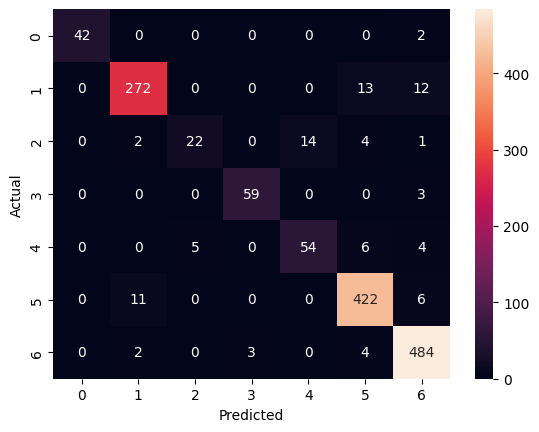

In [103]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [104]:
processed = prepare_features(shipment_df, feature_columns)  # Process the data using the same feature engineering steps as during training

In [105]:
top3 = predict_flights(model, encoder, processed.iloc[[0]])
print(top3)

    Flight  Probability
6   QR 557    64.543932
5  FX 5487    22.729019
4  FX 5460     5.481457


In [106]:
print("COLUMNS:",capacity_df.columns)

COLUMNS: Index(['Airline', 'Day_of_Week', 'Capacity_KG', 'Day_Num', 'Loaded_So_Far',
       'Remaining_Capacity', 'Load_Percentage'],
      dtype='object')


In [107]:
print("COLUMNS:",shipment_df.columns)

COLUMNS: Index(['AWB', 'Pieces', 'Weight', 'Invoice Value', 'Weight_Category',
       'Service', 'Split', 'Flight_Number', 'Clearence_Delay',
       'Shipment Pickup Date', 'Shipment Pickup_DOW',
       'Shipment received date by the CLH team',
       'Shipment Handover date to Ramp by the CLH Team', 'Commit Date',
       'Flight_Takeoff_Date', 'Airline_Code',
       'Shipment handover day to the ramp',
       'NO.Of Days between Pickup Date and Flight Takeoff', 'Delivery_Window',
       'NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE', 'Route_Type',
       'Destination_Hub', 'Pickup Weekday Number', 'Weight per Piece',
       'Urgency_Level', 'Weekend_Pickup', 'Service_Priority', 'Airline',
       'Operating_Day', 'Operating_Day_Num', 'Days_to_Flight', 'Day_of_Week',
       'Capacity_KG', 'Day_Num', 'Loaded_So_Far', 'Remaining_Capacity',
       'Load_Percentage', 'Capacity_Ratio', 'Flight_Full', 'Flight_Label',
       'Clearance_Delay', 'Weight_to_Capacity'],
      dtype='object')


In [108]:
print("COLUMNS:",schedule_df.columns)

COLUMNS: Index(['Flight_Number', 'Airline', 'Operating_Day'], dtype='object')


In [109]:
row = shipment_df.iloc[0]

print("\n========= SHIPMENT INFO =========")
print("Pickup Day (Name):", row["Shipment Pickup_DOW"])
print("Pickup Day (Number):", row["Pickup Weekday Number"])
print("Pickup Date:", row["Shipment Pickup Date"])
print("=================================\n")

assigned_flights = []
flight_days = []    
shipment_weight = row["Weight"]
pickup_day_num = row["Pickup Weekday Number"]
service = row["Service"]
destination = row["Destination_Hub"]
origin = "BOM"

result = assign_flight(
    top3,
    shipment_weight,
    capacity_df,
    pickup_day_num,
    service,
    destination,
    routes_df,
    origin,
    schedule_df
)

# Handle return format safely

if isinstance(result, tuple):
    if len(result) == 3:
        best_flight, flight_day, flight_day_num = result
    else:
        best_flight, flight_day = result
        flight_day_num = None
else:
    best_flight = result
    flight_day = None
    flight_day_num = None


print("\n========= FINAL DECISION =========")

print("Pickup Day:", row["Shipment Pickup_DOW"])
print("Assigned Flight:", best_flight)
print("Flight Day:", flight_day)

if flight_day_num:
    delay = flight_day_num - pickup_day_num
    if delay < 0:
        delay += 7
    print("Delay (days):", delay)

print("=================================\n")




========= SHIPMENT INFO =========
Pickup Day (Name): Saturday
Pickup Day (Number): 6.0
Pickup Date: 2026-01-10 00:00:00

Valid Operating Days: ['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
Earliest Allowed Day: 1.0
Flitered Capacity Rows:
   Airline Day_of_Week  Day_Num
5       QR     Tuesday        2
6       QR   Wednesday        3
7       QR    Thursday        4
8       QR      Friday        5
9       QR    Saturday        6
10      QR      Sunday        7
5       QR     Tuesday        2
6       QR   Wednesday        3
7       QR    Thursday        4
8       QR      Friday        5
9       QR    Saturday        6
10      QR      Sunday        7

========= FINAL DECISION =========
Pickup Day: Saturday
Assigned Flight: QR557
Flight Day: Tuesday
Delay (days): 3.0



In [110]:
prepare_features(shipment_df, feature_columns)


,Weight,Pieces,Invoice Value,Weight per Piece,Service_Priority,Weekend_Pickup,Clearence_Delay,Pickup Weekday Number,Days_to_Flight,Delivery_Window,...,Urgency_Level_High,Urgency_Level_Low,Urgency_Level_Medium,Destination_Hub_CAN,Destination_Hub_CDG,Destination_Hub_DXB,Destination_Hub_LHR,Destination_Hub_MEM,Route_Type_Direct,Route_Type_Hub
0,17.50,1.0,46602.78,17.500000,3,0,1.0,6.0,0.0,6.0,...,False,False,True,False,False,False,False,True,0,0
1,73.00,6.0,87139.80,12.166667,3,0,0.0,5.0,2.0,11.0,...,False,True,False,False,False,False,False,True,0,0
2,1.50,2.0,3750.00,0.750000,3,0,1.0,6.0,0.0,9.0,...,False,True,False,False,True,False,False,False,0,0
3,10.50,1.0,158415.00,10.500000,3,0,1.0,5.0,4.0,28.0,...,False,True,False,False,False,False,False,True,0,0
4,13.00,1.0,13365.00,13.000000,3,0,1.0,2.0,4.0,9.0,...,False,True,False,False,True,False,False,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7227,4.00,2.0,117715.65,2.000000,1,0,1.0,5.0,1.0,6.0,...,False,False,True,False,True,False,False,False,0,0
7228,142.00,1.0,199584.00,142.000000,4,0,1.0,2.0,5.0,14.0,...,False,True,False,False,False,False,False,True,0,0
7229,1.00,1.0,104.25,1.000000,1,0,1.0,4.0,2.0,6.0,...,False,False,True,False,False,False,False,True,0,0
7230,2.50,1.0,34838.10,2.500000,1,0,1.0,5.0,4.0,6.0,...,False,False,True,False,False,False,False,True,0,0
